In [24]:
import ucimlrepo
import pandas as pd

from ucimlrepo import fetch_ucirepo

# fetch dataset
car_evaluation = fetch_ucirepo(id=19)

# data (as pandas dataframes)
X = car_evaluation.data.features
y = car_evaluation.data.targets

# metadata
print(car_evaluation.metadata)

# variable information
print(car_evaluation.variables)
df = pd.concat([X, y], axis=1)
df.head()

     buying  maint  doors persons lug_boot safety
0     vhigh  vhigh      2       2    small    low
1     vhigh  vhigh      2       2    small    med
2     vhigh  vhigh      2       2    small   high
3     vhigh  vhigh      2       2      med    low
4     vhigh  vhigh      2       2      med    med
...     ...    ...    ...     ...      ...    ...
1723    low    low  5more    more      med    med
1724    low    low  5more    more      med   high
1725    low    low  5more    more      big    low
1726    low    low  5more    more      big    med
1727    low    low  5more    more      big   high

[1728 rows x 6 columns]


In [19]:
#1.data inspeciton
print(df.shape)
print(df.dtypes)
print(df.describe())
df.isnull().sum()
for column in df.columns:
    print(f"{column}:")
    print(df[column].value_counts())
    print()

(1728, 7)
buying      str
maint       str
doors       str
persons     str
lug_boot    str
safety      str
class       str
dtype: object
       buying  maint doors persons lug_boot safety  class
count    1728   1728  1728    1728     1728   1728   1728
unique      4      4     4       3        3      3      4
top     vhigh  vhigh     2       2    small    low  unacc
freq      432    432   432     576      576    576   1210
buying:
buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64

maint:
maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64

doors:
doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64

persons:
persons
2       576
4       576
more    576
Name: count, dtype: int64

lug_boot:
lug_boot
small    576
med      576
big      576
Name: count, dtype: int64

safety:
safety
low     576
med     576
high    576
Name: count, dtype: int64

class:
class
unacc    1210
acc       384
good       6

### Univariate Analysis

The six input features were analyzed using count plots. All features are categorical variables.

The results show that the categories within each feature are evenly distributed. The buying price, maintenance cost, and number of doors each have four categories, with 432 samples per category. The number of persons, luggage boot size, and safety level each have three categories, with 576 samples per category.

Overall, the distributions of all six input features are balanced. However, this does not necessarily mean that the target classes are balanced or that all features have the same importance in predicting car acceptability.

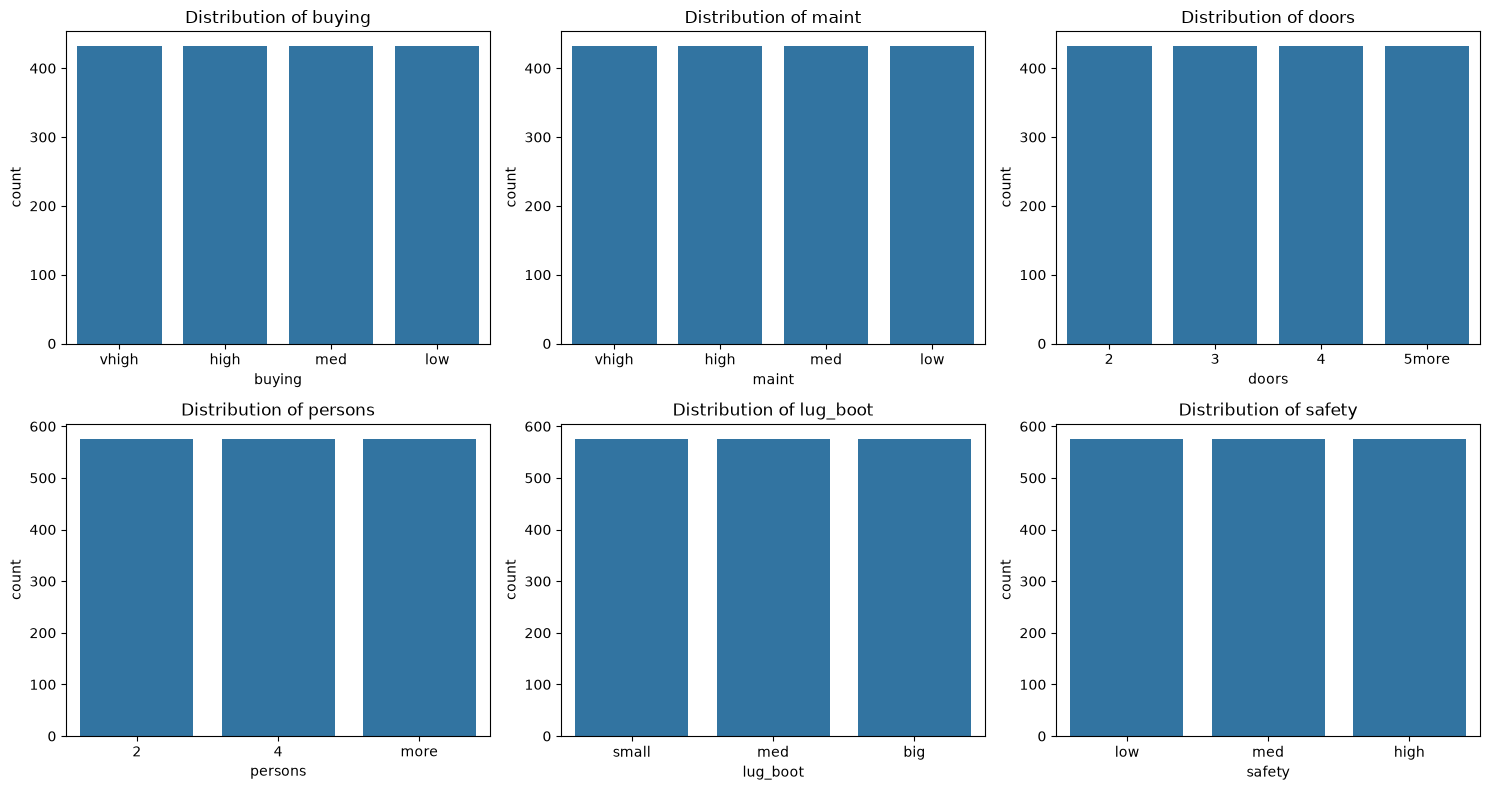

In [25]:
#2. Exploratory data analysis
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, column in enumerate(X.columns):
    ax = axes.flat[i]
    sns.countplot(data=X, x=column, ax=ax)
    ax.set_title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

### Categorical Features vs. Target

The grouped bar charts show the relationships between the six categorical features and car evaluation classes.

Safety and passenger capacity show clear differences in the target distributions. All cars with low safety levels are classified as unacceptable. Similarly, all cars with a passenger capacity of two are classified as unacceptable.

Buying price and maintenance cost also appear to be related to car acceptability. Cars with lower costs generally have more favorable evaluation results.

In contrast, the distributions across the number of doors are relatively similar, suggesting that this feature may be less informative when considered alone.

Overall, safety and passenger capacity appear to be particularly useful features for predicting car acceptability.

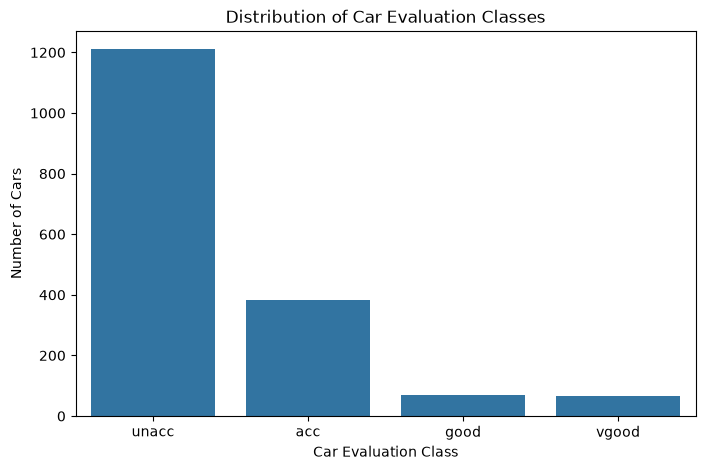

In [26]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='class',
    order=['unacc', 'acc', 'good', 'vgood']
)

plt.title('Distribution of Car Evaluation Classes')
plt.xlabel('Car Evaluation Class')
plt.ylabel('Number of Cars')
plt.show()

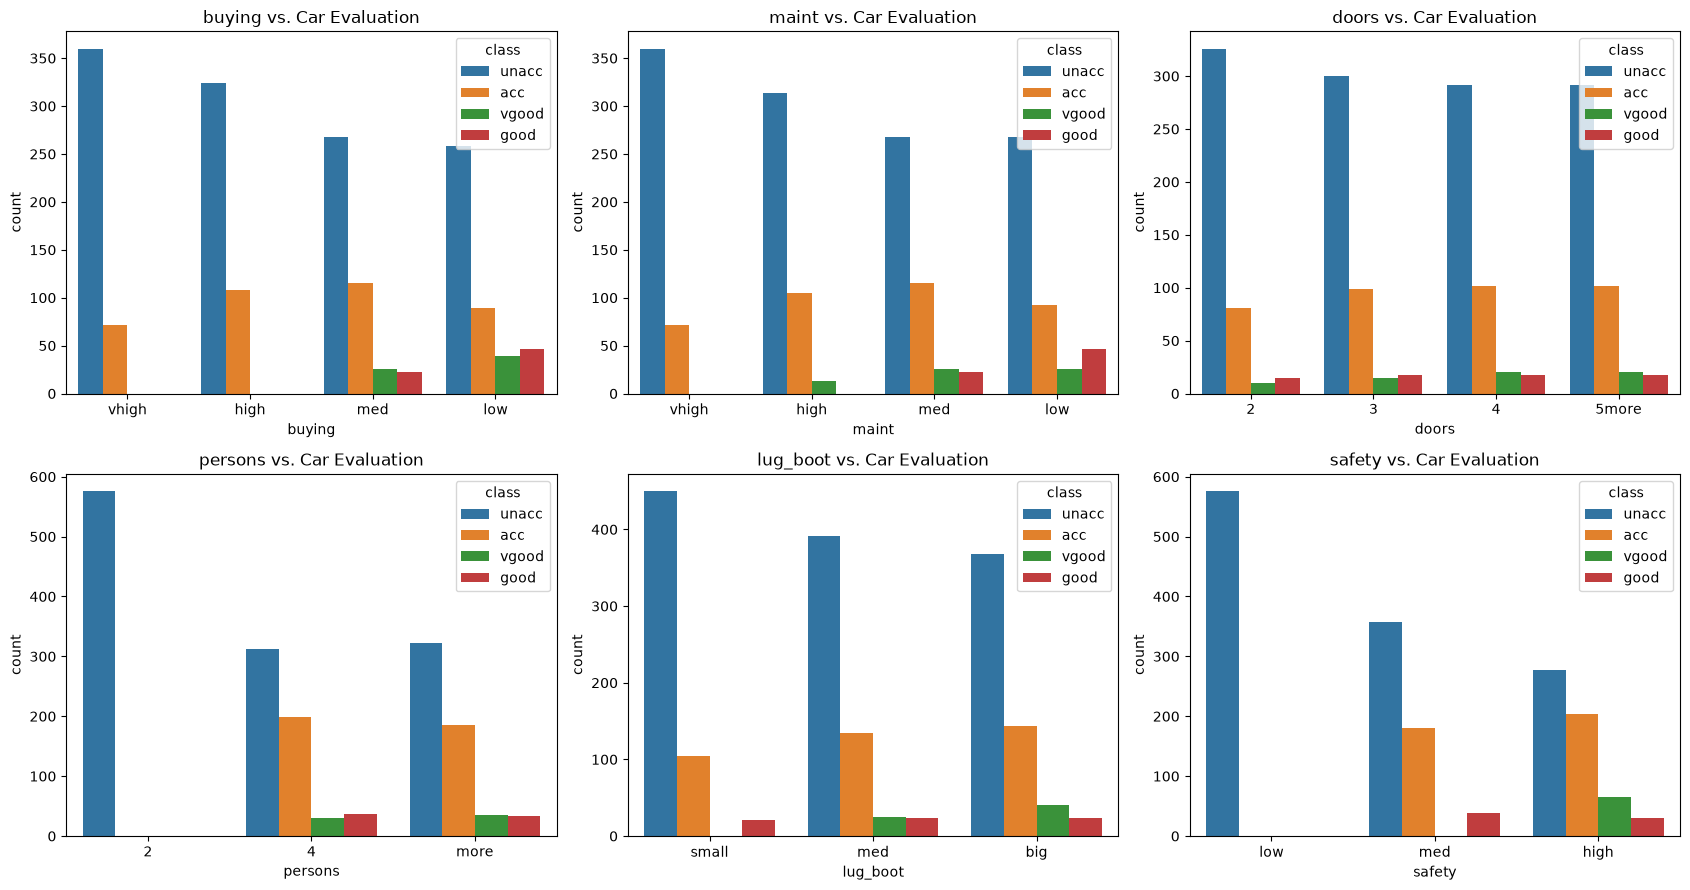

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

for i, column in enumerate(X.columns):
    ax = axes.flat[i]

    sns.countplot(
        data=df,
        x=column,
        hue='class',
        ax=ax
    )

    ax.set_title(f'{column} vs. Car Evaluation')

plt.tight_layout()
plt.show()